<a href="https://colab.research.google.com/github/vir123-devf/Face_mask_detection_using_cnn/blob/main/Face_Mask_Detection_using_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
!pip install kaggle

In [46]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [47]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [48]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'
with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('dataset is extracted')

dataset is extracted


In [49]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split


In [51]:
with_mask = os.listdir('/content/data/with_mask')
without_mask = os.listdir("/content/data/without_mask")


In [52]:
print(with_mask)
print(without_mask)

['with_mask_94.jpg', 'with_mask_2145.jpg', 'with_mask_606.jpg', 'with_mask_2978.jpg', 'with_mask_3281.jpg', 'with_mask_2667.jpg', 'with_mask_1735.jpg', 'with_mask_1086.jpg', 'with_mask_467.jpg', 'with_mask_3170.jpg', 'with_mask_1089.jpg', 'with_mask_3076.jpg', 'with_mask_869.jpg', 'with_mask_2194.jpg', 'with_mask_1398.jpg', 'with_mask_2648.jpg', 'with_mask_3581.jpg', 'with_mask_3725.jpg', 'with_mask_933.jpg', 'with_mask_744.jpg', 'with_mask_1879.jpg', 'with_mask_607.jpg', 'with_mask_514.jpg', 'with_mask_2509.jpg', 'with_mask_2808.jpg', 'with_mask_1265.jpg', 'with_mask_301.jpg', 'with_mask_3247.jpg', 'with_mask_1336.jpg', 'with_mask_3045.jpg', 'with_mask_469.jpg', 'with_mask_3141.jpg', 'with_mask_1651.jpg', 'with_mask_1864.jpg', 'with_mask_260.jpg', 'with_mask_2470.jpg', 'with_mask_727.jpg', 'with_mask_3175.jpg', 'with_mask_290.jpg', 'with_mask_1310.jpg', 'with_mask_2280.jpg', 'with_mask_1420.jpg', 'with_mask_19.jpg', 'with_mask_2581.jpg', 'with_mask_730.jpg', 'with_mask_2900.jpg', 'wit

In [53]:
print(len(with_mask))
print(len(without_mask))

3725
3828


In [54]:
# with mask ---> 1
# without mask ---> 0

with_mask_labels =[1]*3725
without_mask_labels =[0]*3828


In [55]:
labels = with_mask_labels +without_mask_labels
print(len(labels))
print(labels[:5])

7553
[1, 1, 1, 1, 1]


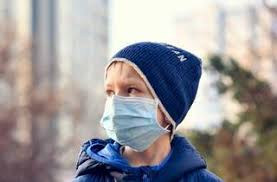

In [56]:
img = cv2.imread('/content/data/with_mask/with_mask_827.jpg')
cv2_imshow(img)

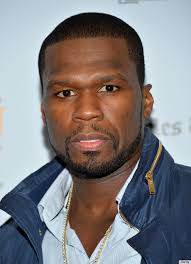

In [57]:
img = cv2.imread('/content/data/without_mask/without_mask_2612.jpg')
cv2_imshow(img)

In [58]:
# image Processing
with_mask_path = '/content/data/with_mask/'
without_mask_path = '/content/data/without_mask/'

data =[]
for img_jpg in with_mask:
  img  = Image.open(with_mask_path+img_jpg)
  img = img.resize((100,100))
  img = img.convert('RGB')
  img = np.array(img)
  data.append(img)
for img_jpg in without_mask:
  img  = Image.open(without_mask_path+img_jpg)
  img = img.resize((100,100))
  img = img.convert('RGB')
  img = np.array(img)
  data.append(img)



/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [59]:
type(data)

list

In [60]:
len(data)

7553

array([[[105,  87,  75],
        [100,  83,  71],
        [ 91,  74,  64],
        ...,
        [ 79,  61,  46],
        [ 77,  58,  41],
        [ 93,  72,  55]],

       [[ 98,  80,  68],
        [116,  98,  86],
        [ 86,  68,  59],
        ...,
        [ 82,  64,  49],
        [ 76,  57,  41],
        [ 79,  58,  41]],

       [[ 88,  70,  58],
        [ 93,  75,  64],
        [ 77,  60,  50],
        ...,
        [ 86,  67,  52],
        [ 88,  69,  52],
        [ 82,  61,  44]],

       ...,

       [[151, 109,  95],
        [139,  96,  83],
        [141,  97,  85],
        ...,
        [183, 161, 132],
        [183, 162, 135],
        [182, 162, 136]],

       [[151, 109,  98],
        [137,  95,  83],
        [137,  93,  82],
        ...,
        [184, 163, 134],
        [183, 162, 133],
        [181, 161, 132]],

       [[150, 107,  98],
        [132,  89,  80],
        [133,  89,  80],
        ...,
        [182, 161, 132],
        [182, 163, 131],
        [182, 162, 129]]], dtype=uint8)
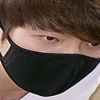

In [61]:
data[0]

In [62]:
x= np.array(data)
y = np.array(labels)

In [63]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=0)

In [64]:
print(x.shape,x_train.shape,x_test.shape)

(7553, 100, 100, 3) (6042, 100, 100, 3) (1511, 100, 100, 3)


In [65]:
x_train_scaled = x_train/255
x_test_scaled = x_test/255

In [66]:
x_train_scaled[1]

array([[[0.5254902 , 0.45098039, 0.38431373],
        [0.52941176, 0.45490196, 0.38823529],
        [0.52941176, 0.45490196, 0.38823529],
        ...,
        [0.12941176, 0.00784314, 0.00784314],
        [0.13333333, 0.01568627, 0.00392157],
        [0.14509804, 0.01176471, 0.00392157]],

       [[0.5254902 , 0.45098039, 0.38431373],
        [0.52941176, 0.45490196, 0.38823529],
        [0.52941176, 0.45490196, 0.38823529],
        ...,
        [0.12941176, 0.00784314, 0.00784314],
        [0.13333333, 0.01568627, 0.00392157],
        [0.14509804, 0.01176471, 0.00392157]],

       [[0.5254902 , 0.45098039, 0.38431373],
        [0.52941176, 0.45490196, 0.38823529],
        [0.52941176, 0.45490196, 0.38823529],
        ...,
        [0.12941176, 0.00784314, 0.00784314],
        [0.13333333, 0.01568627, 0.00392157],
        [0.14509804, 0.01176471, 0.00392157]],

       ...,

       [[0.90588235, 0.25490196, 0.27058824],
        [0.90588235, 0.23529412, 0.25098039],
        [0.89803922, 0

In [67]:
import tensorflow
from tensorflow.keras import Sequential,layers

In [74]:
# Building cnn
no_of_classes = 2

model = Sequential()
model.add(layers.Conv2D(32,3,activation='relu',input_shape=(100,100,3)))
model.add(layers.MaxPooling2D(pool_size=(2,2),strides=(1,1)))
model.add(layers.Conv2D(64,3,activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2,2),strides=(1,1)))
model.add(layers.Flatten())
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(no_of_classes,activation ='sigmoid'))




/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
# compiling the model
model.compile(optimizer = 'adam',loss='sparse_categorical_crossentropy',metrics = ['accuracy'])

In [76]:
# Training the model
h = model.fit(x_train_scaled,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - accuracy: 0.6588 - loss: 1.6906 - val_accuracy: 0.7833 - val_loss: 0.4349
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8685 - loss: 0.3528 - val_accuracy: 0.8238 - val_loss: 0.4002
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.8809 - loss: 0.3124 - val_accuracy: 0.8685 - val_loss: 0.3157
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.8788 - loss: 0.3292 - val_accuracy: 0.8974 - val_loss: 0.2363
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9111 - loss: 0.2286 - val_accuracy: 0.9057 - val_loss: 0.2508
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9390 - loss: 0.1691 - val_accuracy: 0.8958 - val_loss: 0.2716
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9545 - loss: 0.1483 - val_accuracy: 0.9214 - val_loss: 0.2247
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9624 - loss: 0.1143 - val_a

In [78]:
# model Evaluation
loss,accuracy = model.evaluate(x_test_scaled,y_test)

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9223 - loss: 0.3124


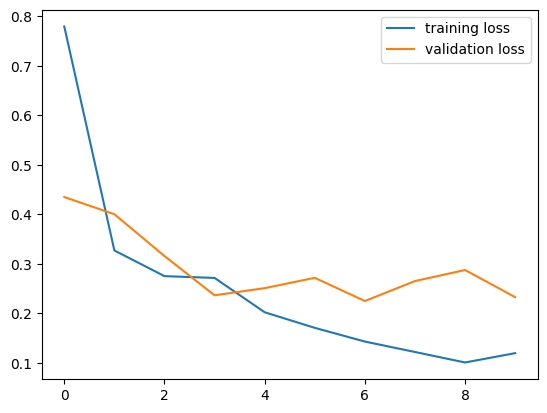

In [79]:
plt.plot(h.history['loss'],label ='training loss')
plt.plot(h.history['val_loss'],label ='validation loss')
plt.legend()
plt.show()

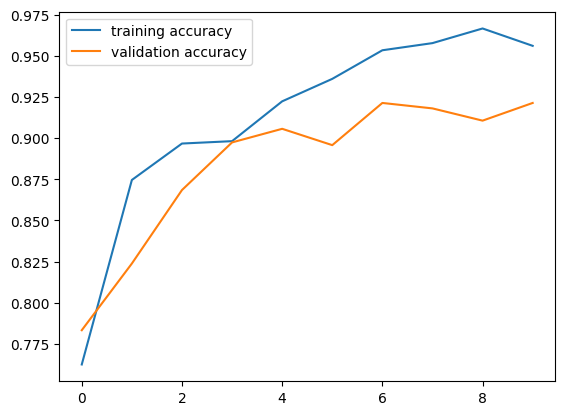

In [80]:
plt.plot(h.history['accuracy'],label ='training accuracy')
plt.plot(h.history['val_accuracy'],label ='validation accuracy')
plt.legend()
plt.show()

Let's build a Predictive system

Enter the path of downloaded image: /content/images.jpg


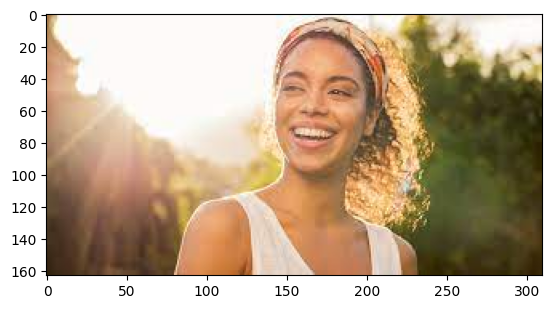

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Person is not wearing mask


In [88]:
# predicting for downloaded image(jpg) from website-
from matplotlib import image as mpimg
from PIL import Image
path = input("Enter the path of downloaded image: ")
img2 = mpimg.imread(path)
imgplt = plt.imshow(img2)
plt.show()

img1 = Image.open(path)
img1 = img1.resize((100,100))
img1 = img1.convert('RGB')
img1 = np.array(img1)
img1 = img1 / 255.0  # optional depending on model preprocessing

# Add batch dimension ---> important step ---(1,100,100,3)
img1 = np.expand_dims(img1, axis=0)

# Predict
y_p = model.predict(img1)
y_predicted = y_p.argmax(axis=1)
y_predicted
if y_predicted == [1]:
  print('Person is wearing mask')
else:
  print('Person is not wearing mask')


Enter the path of downloaded image: /content/istockphoto-1217604429-612x612.jpg


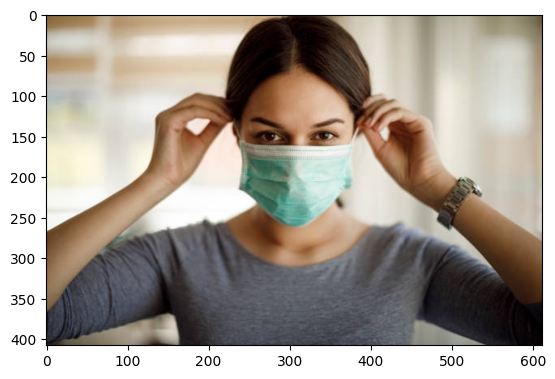

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Person is wearing mask


In [89]:
# predicting for downloaded image(jpg) from website-
from matplotlib import image as mpimg
from PIL import Image
path = input("Enter the path of downloaded image: ")
img2 = mpimg.imread(path)
imgplt = plt.imshow(img2)
plt.show()

img1 = Image.open(path)
img1 = img1.resize((100,100))
img1 = img1.convert('RGB')
img1 = np.array(img1)
img1 = img1 / 255.0  # optional depending on model preprocessing

# Add batch dimension ---> important step ---(1,100,100,3)
img1 = np.expand_dims(img1, axis=0)

# Predict
y_p = model.predict(img1)
y_predicted = y_p.argmax(axis=1)
y_predicted
if y_predicted == [1]:
  print('Person is wearing mask')
else:
  print('Person is not wearing mask')